# 02 — Spatial Overview Maps

Produces three figures:
- **Figure 8**: Locations of all restored USGS water data in the continental USA (actual vs inferred coordinates distinguished)
- **Figure 9**: California locations colored by water type
- **Figure 10**: California locations by decade (multi-panel)

Requires `data/analysis/processed_metadata.parquet` (output of `00_data_prep.ipynb`).

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import sys
sys.path.insert(0, str(Path('.')))
from water_palette import CATEGORY_ORDER, get_color_for

root         = Path('../..')
parquet_path = root / 'data/analysis/processed_metadata.parquet'
spatial_path = root / 'data/analysis/spatial'
figures_path = root / 'manuscript/figures'
figures_path.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df):,} rows')

Loaded 109,440 rows


## Build spatial dataset

In [2]:
WATER_CATEGORIES = [
    'Stream Discharge', 'Groundwater', 'Reservoir',
    'Irrigation', 'Springs', 'Precipitation', 'Water Quality'
]

# Drop rows without coordinates or water category
df_geo = df[
    df['lat_combined'].notna() &
    df['lon_combined'].notna() &
    df['water_type_clean'].isin(WATER_CATEGORIES)
].copy()

# Deduplicate to unique locations (one point per unique lat/lon/water_type combo)
df_geo = df_geo.drop_duplicates(subset=['lat_combined', 'lon_combined', 'water_type_clean'])

gdf = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo['lon_combined'], df_geo['lat_combined']),
    crs='EPSG:4326'
)
print(f'{len(gdf):,} unique location/water-type combinations')

58,474 unique location/water-type combinations


## Load shapefiles

In [3]:
usa   = gpd.read_file(spatial_path / 'usa_shapefile/CUSA_States.shp').to_crs('EPSG:4326')
ca    = gpd.read_file(spatial_path / 'ca_shapefile/ca_poly.shp').to_crs('EPSG:4326')
print('Shapefiles loaded')

Shapefiles loaded


## Figure 8 — Continental USA map

Dark blue = actual coordinates from document; light blue = inferred by LLM geolocation.

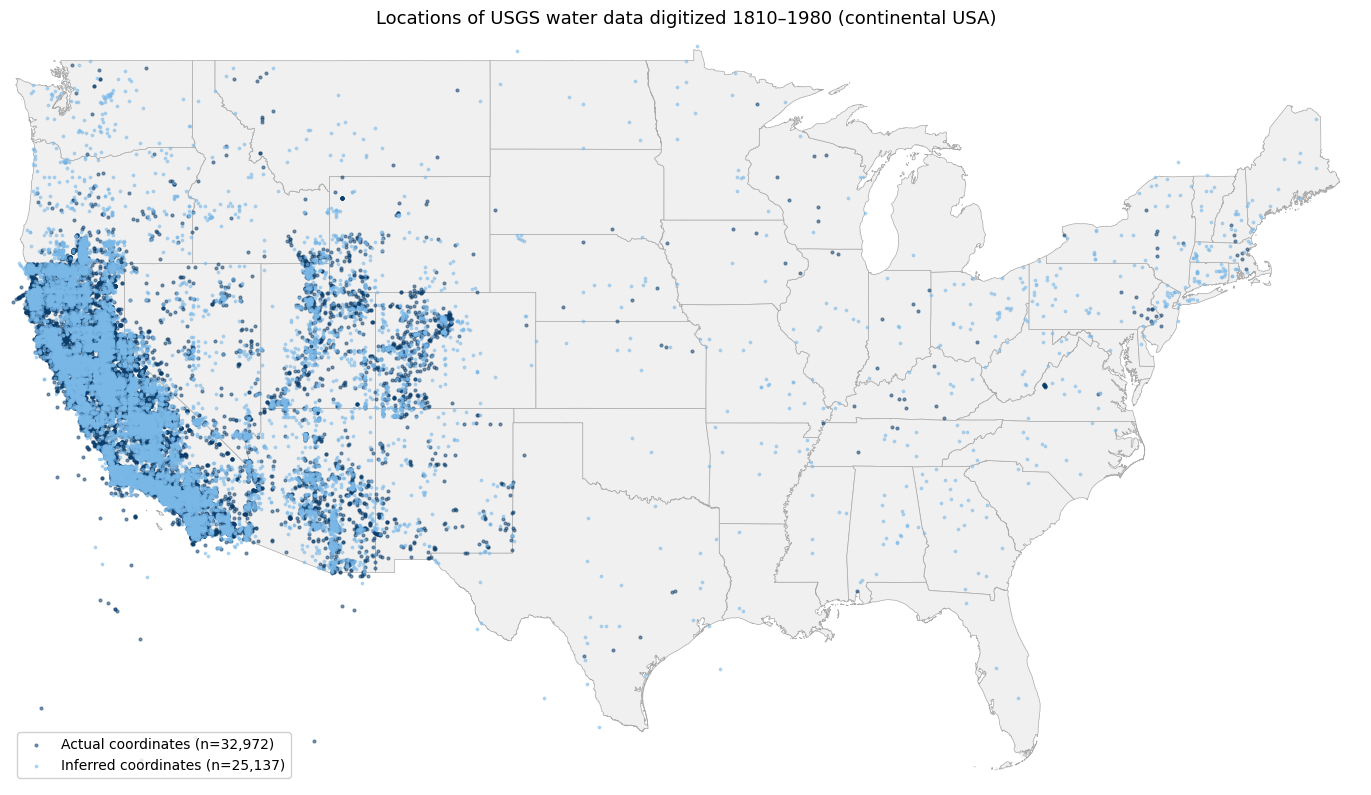

Saved usa_map.png


In [4]:
# Filter to continental US bounding box
usa_bbox = (-125, 24, -66, 50)
gdf_usa = gdf.cx[usa_bbox[0]:usa_bbox[2], usa_bbox[1]:usa_bbox[3]]

fig, ax = plt.subplots(figsize=(14, 8))
usa.plot(ax=ax, color='#f0f0f0', edgecolor='#aaaaaa', linewidth=0.5)

for source, color, label, size in [
    ('actual',   '#0a3d6b', 'Actual coordinates',   4),
    ('inferred', '#7ab8e8', 'Inferred coordinates', 3),
]:
    sub = gdf_usa[gdf_usa['coord_source'] == source]
    sub.plot(ax=ax, color=color, markersize=size, alpha=0.5, marker='o', label=f'{label} (n={len(sub):,})')

ax.set_xlim(usa_bbox[0], usa_bbox[2])
ax.set_ylim(usa_bbox[1], usa_bbox[3])
ax.set_axis_off()
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.set_title('Locations of USGS water data digitized 1810–1980 (continental USA)', fontsize=13)

plt.tight_layout()
plt.savefig(figures_path / 'usa_map.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved usa_map.png')

## Figure 9 — California map by water type

50,021 points within California


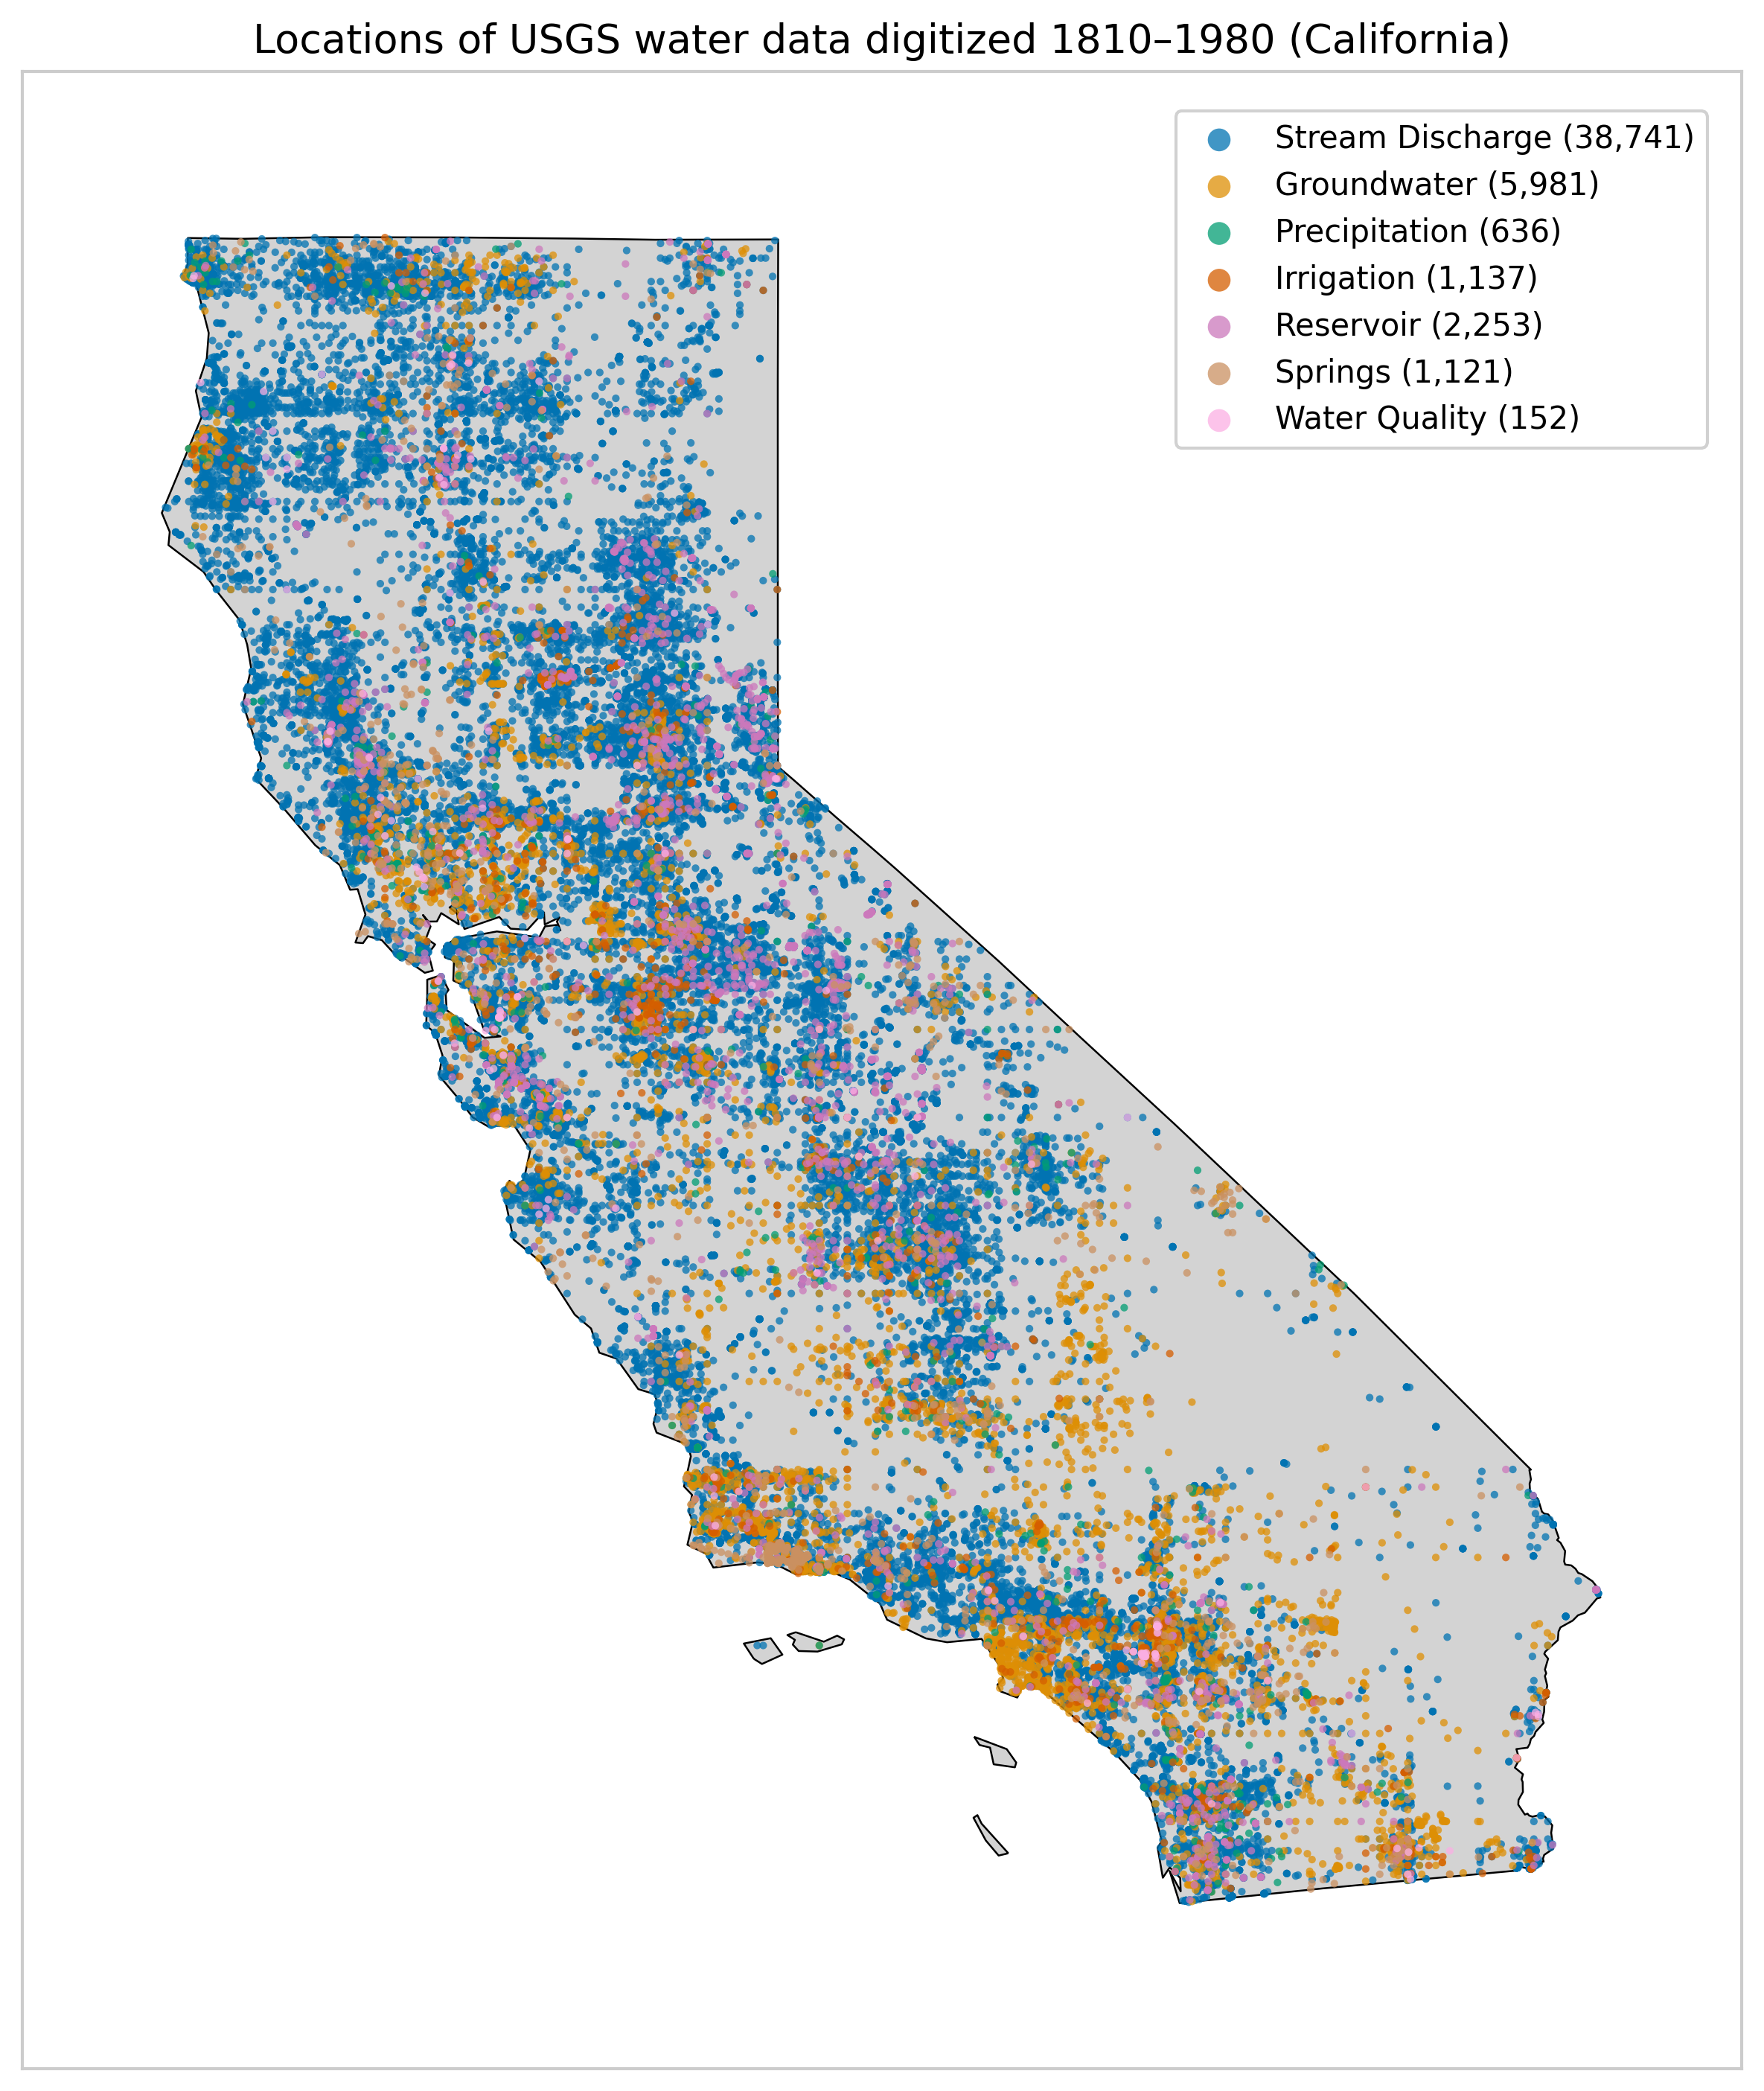

Saved ca_map_by_water_type.png


In [5]:
# Spatial filter to California
gdf_ca = gpd.sjoin(gdf, ca[['geometry']], how='inner', predicate='within')
print(f'{len(gdf_ca):,} points within California')

cols_ordered = [c for c in CATEGORY_ORDER if c in gdf_ca['water_type_clean'].unique()]

# Padded extent from data bounds (consistent across all CA figures)
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
CA_XMIN, CA_YMIN = minx - pad_lon, miny - pad_lat
CA_XMAX, CA_YMAX = maxx + pad_lon, maxy + pad_lat

fig, ax = plt.subplots(figsize=(8, 10), dpi=300)
ca.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.6, zorder=1)

# Plot most common first (on bottom) so rarer types show on top
for wtype in cols_ordered:
    sub = gdf_ca[gdf_ca['water_type_clean'] == wtype]
    sub.plot(ax=ax, color=get_color_for(wtype), markersize=6, alpha=0.75,
             edgecolor='none', linewidth=0, zorder=2, label=f'{wtype} ({len(sub):,})')

ax.set_xlim(CA_XMIN, CA_XMAX)
ax.set_ylim(CA_YMIN, CA_YMAX)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color('#cccccc')
    spine.set_linewidth(1.0)

ax.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98), borderaxespad=0.0,
          ncol=1, markerscale=3.0, frameon=True, fancybox=True, framealpha=0.9)
ax.set_title('Locations of USGS water data digitized 1810–1980 (California)', fontsize=13)

plt.tight_layout()
plt.savefig(figures_path / 'ca_map_by_water_type.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved ca_map_by_water_type.png')

## Figure 10 — California by decade (multi-panel)

Decades with data: [np.int64(1810), np.int64(1820), np.int64(1840), np.int64(1850), np.int64(1860), np.int64(1870), np.int64(1880), np.int64(1890), np.int64(1900), np.int64(1910), np.int64(1920), np.int64(1930), np.int64(1940), np.int64(1950), np.int64(1960), np.int64(1970), np.int64(1980)]


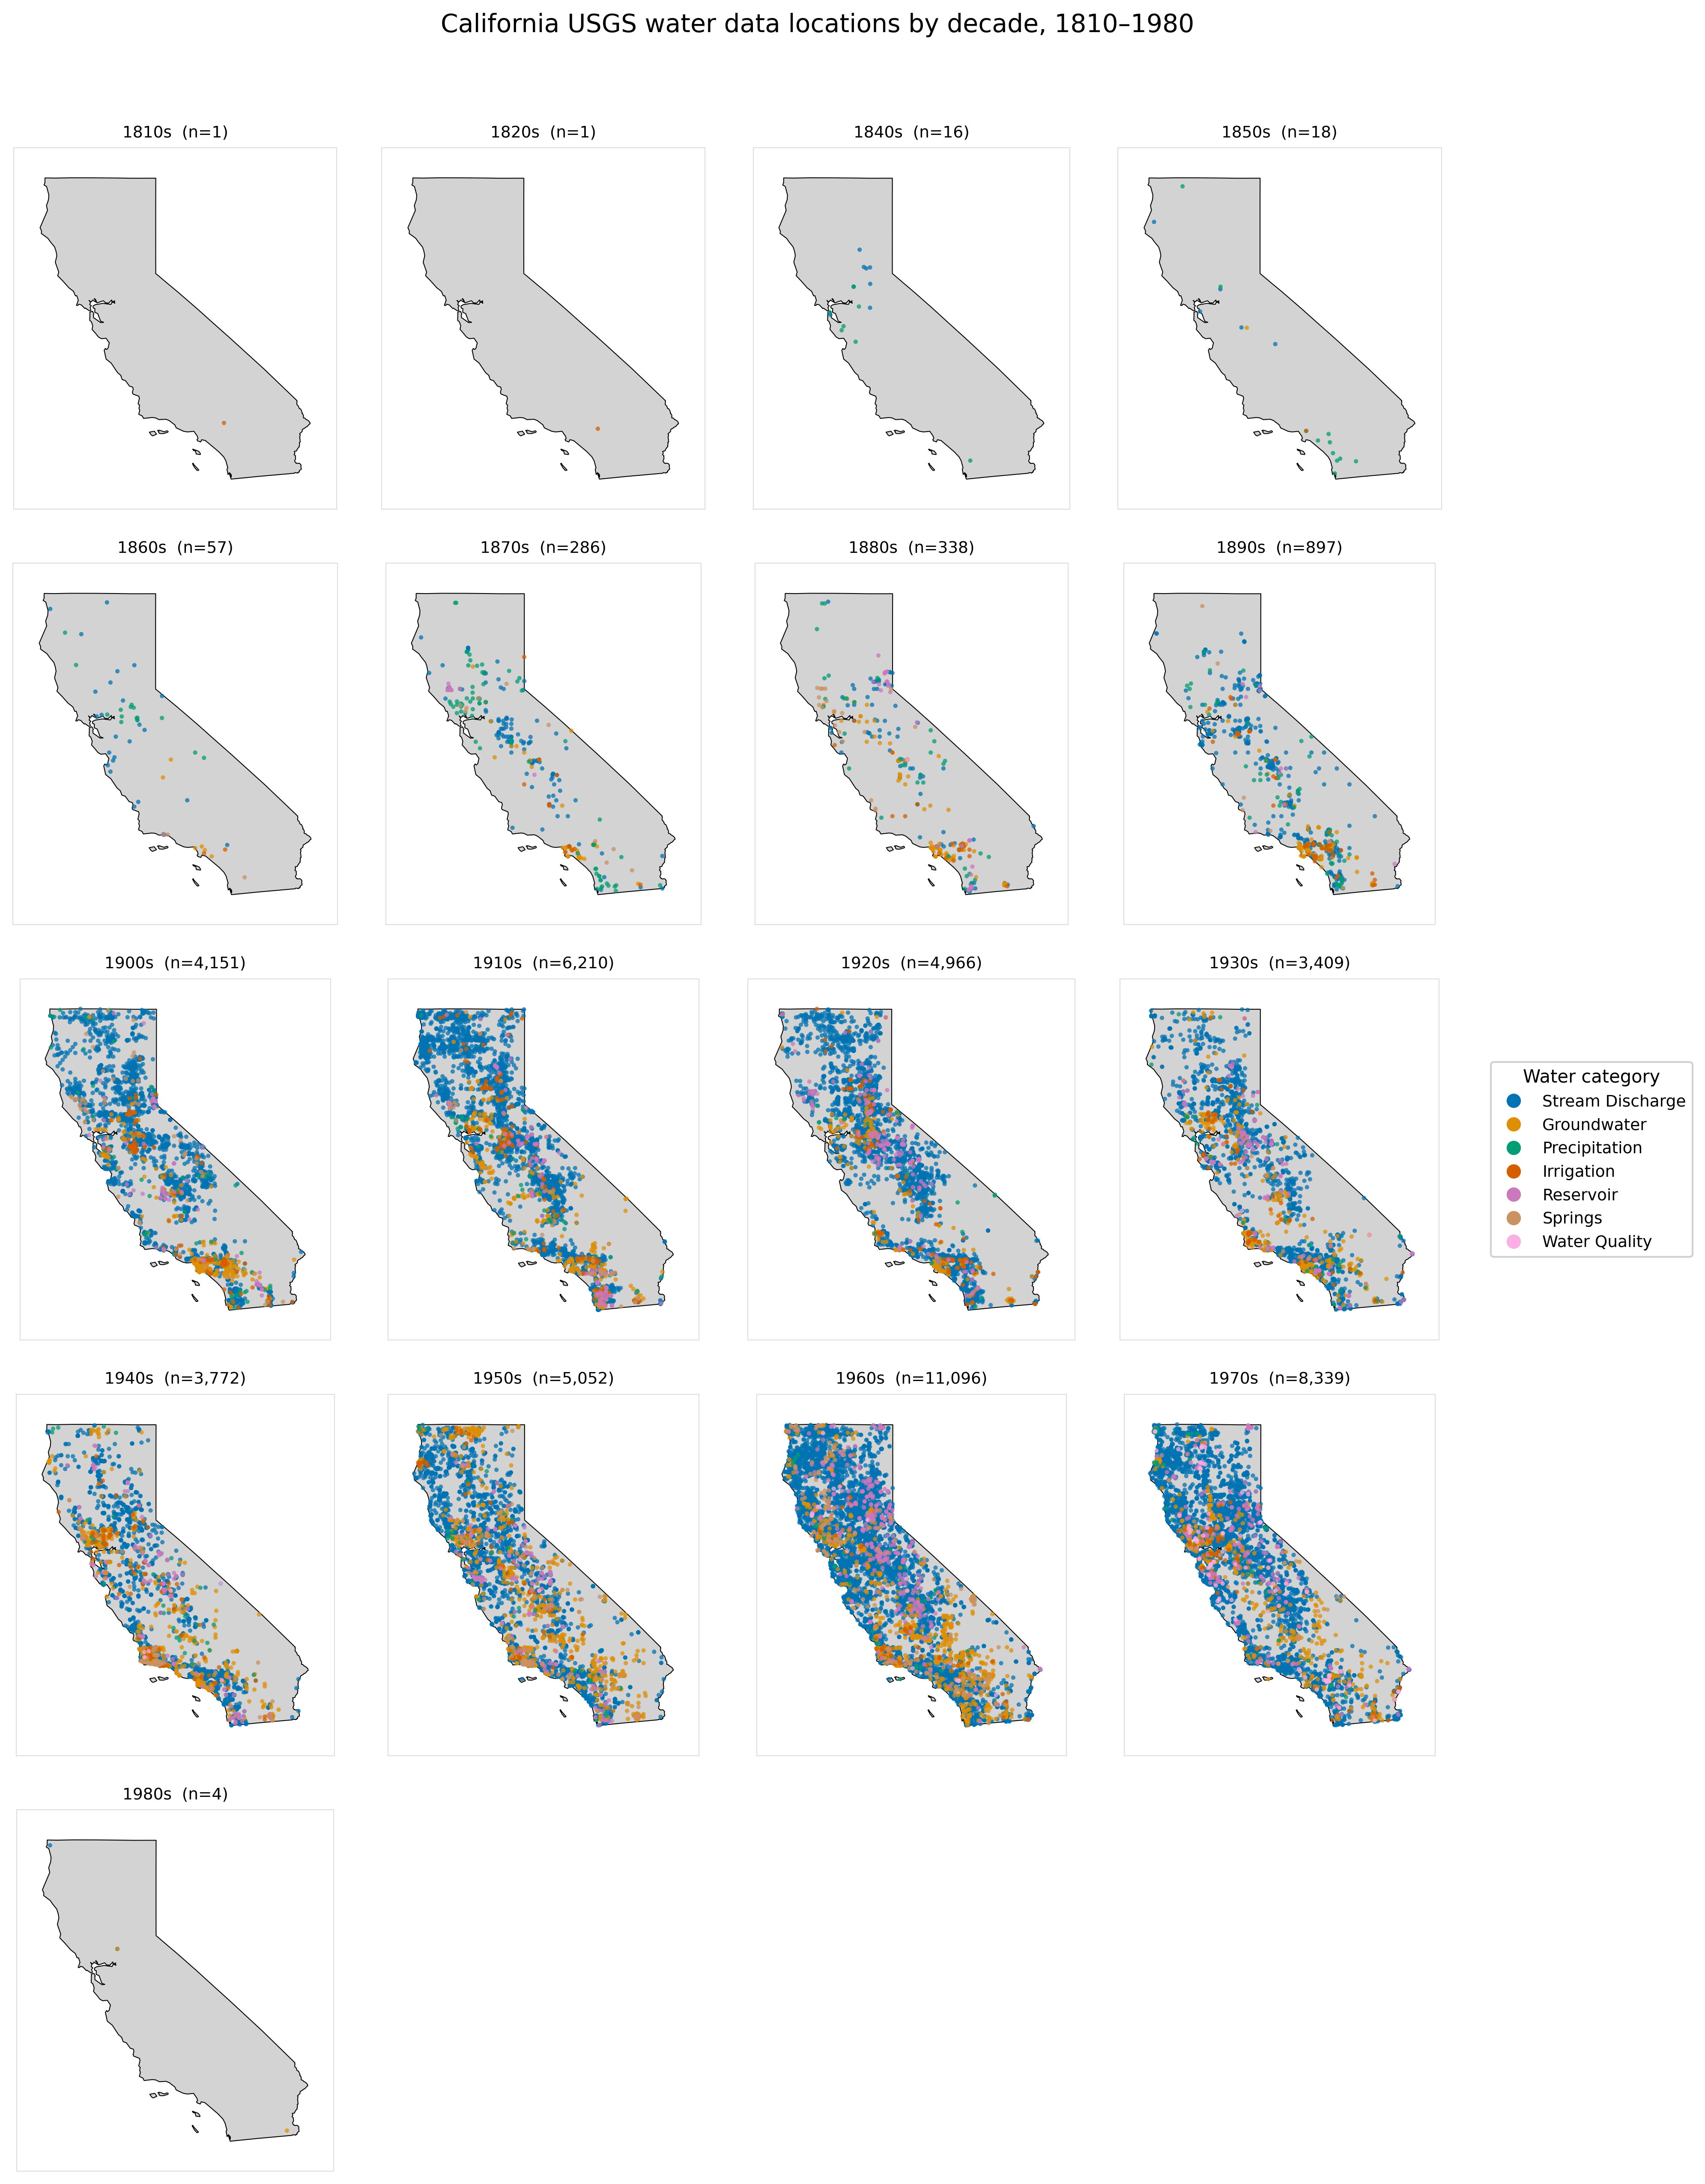

Saved ca_map_by_decade.png


In [6]:
# Re-include decade column; deduplicate per location/watertype/decade
df_geo_decade = df[
    df['lat_combined'].notna() &
    df['lon_combined'].notna() &
    df['water_type_clean'].isin(WATER_CATEGORIES) &
    df['decade_start'].notna()
].drop_duplicates(subset=['lat_combined', 'lon_combined', 'water_type_clean', 'decade_start'])

gdf_decade = gpd.GeoDataFrame(
    df_geo_decade,
    geometry=gpd.points_from_xy(df_geo_decade['lon_combined'], df_geo_decade['lat_combined']),
    crs='EPSG:4326'
)
gdf_decade_ca = gpd.sjoin(gdf_decade, ca[['geometry']], how='inner', predicate='within')

decades = sorted(gdf_decade_ca['decade_start'].dropna().unique().astype(int))
decades = [d for d in decades if 1800 <= d <= 1980]
print(f'Decades with data: {decades}')

n_cols = 4
n_rows = -(-len(decades) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5), dpi=300)
axes = axes.flatten()

plt.subplots_adjust(left=0.05, bottom=0.05, right=0.85, top=0.95, wspace=0.1, hspace=0.15)

for i, decade in enumerate(decades):
    ax = axes[i]
    ca.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5, zorder=1)
    sub = gdf_decade_ca[gdf_decade_ca['decade_start'] == decade]
    for wtype in cols_ordered:
        pts = sub[sub['water_type_clean'] == wtype]
        if not pts.empty:
            pts.plot(ax=ax, color=get_color_for(wtype), markersize=6, alpha=0.75,
                     edgecolor='none', linewidth=0, zorder=2)
    ax.set_xlim(CA_XMIN, CA_XMAX)
    ax.set_ylim(CA_YMIN, CA_YMAX)
    ax.set_title(f'{decade}s  (n={len(sub):,})', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#dddddd')
        spine.set_linewidth(0.5)

for j in range(len(decades), len(axes)):
    axes[j].axis('off')

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='o', linestyle='', markerfacecolor=get_color_for(w),
           markeredgecolor='none', markersize=8, label=w)
    for w in cols_ordered
]
fig.legend(handles=legend_handles, title='Water category',
           loc='center left', bbox_to_anchor=(0.87, 0.5),
           frameon=True, fancybox=True, framealpha=0.9, fontsize=9)
fig.suptitle('California USGS water data locations by decade, 1810–1980', fontsize=14, y=1.01)

plt.savefig(figures_path / 'ca_map_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved ca_map_by_decade.png')